# Wine Quality Prediction

## Objective

To predict wine quality based on its physicochemical properties using machine learning classification models.

### Models Used
- Random Forest Classifier
- Stochastic Gradient Descent (SGD) Classifier
- Support Vector Classifier (SVC)

### Dataset
Wine Quality – Red Wine Dataset from the UCI Machine Learning Repository.

## 1. Import Required Libraries

The following Python libraries are used for data manipulation, visualization,
feature scaling, model building, and model evaluation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")

## 2. Load the Dataset

The Wine Quality dataset contains physicochemical properties of red wine
along with a quality score.

In [3]:
import os

print(os.getcwd())
print(os.listdir())

C:\Users\Vageesha Kriti\OneDrive\Desktop\html\OIBSIP_Data_Analytics
['.ipynb_checkpoints', 'Customer_Segmentation_Analysis.ipynb', 'EDA_Retail_Sales.ipynb', 'Wine_Quality_Prediction.ipynb']


In [4]:
import os

for root, dirs, files in os.walk(r"C:\Users\Vageesha Kriti\OneDrive\Desktop"):
    if "winequality-red.csv" in files:
        print("FOUND:")
        print(os.path.join(root, "winequality-red.csv"))

In [7]:
import pandas as pd

df = pd.read_csv("winequality-red.csv", sep=';')

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (1599, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


## Dataset Structure and Inspection

Before building the models, we inspect the shape, columns and data types of the dataset.

In [8]:
print("Shape of Dataset:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

Shape of Dataset: (1599, 12)

Column Names:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']

Data Types:
fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object


In [9]:
print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Missing Values:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Duplicate Rows: 240


In [10]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


### Observation

The dataset contains physicochemical measurements of red wine samples along with their quality scores.

The descriptive statistics show that the chemical properties have different ranges, which makes feature scaling important for models such as SGD and SVC.

The dataset will also be checked for class imbalance before modelling.

## Exploratory Data Analysis

Exploratory Data Analysis is performed to understand the distribution of wine quality scores and the physicochemical features.

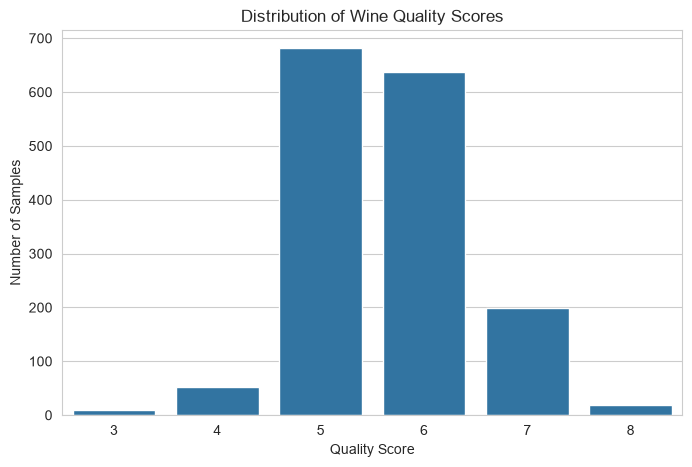

In [11]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x='quality')

plt.title('Distribution of Wine Quality Scores')
plt.xlabel('Quality Score')
plt.ylabel('Number of Samples')

plt.show()

### Observation

The quality scores are not evenly distributed.

Some quality scores have many more observations than others, while extreme quality scores are comparatively underrepresented. This class imbalance can affect classification performance because a model may become biased toward the majority classes.

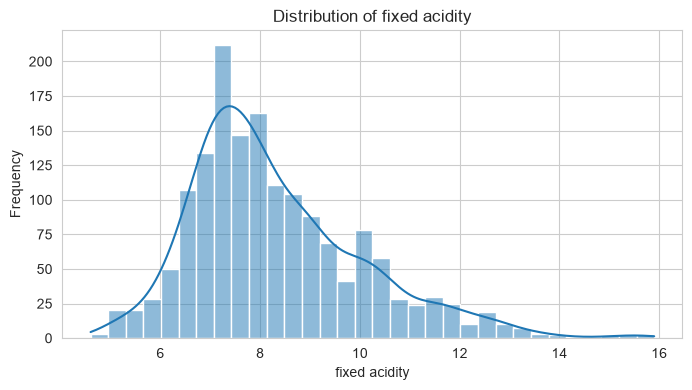

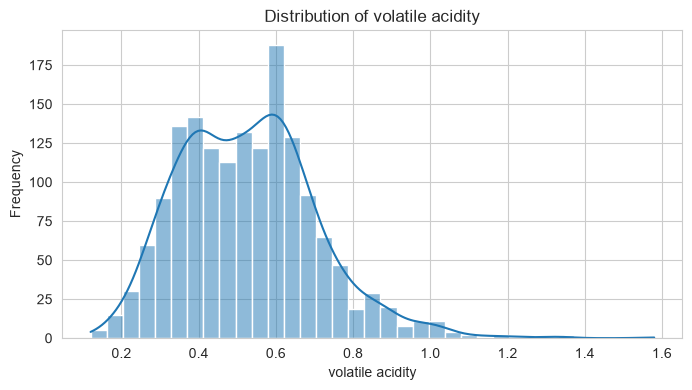

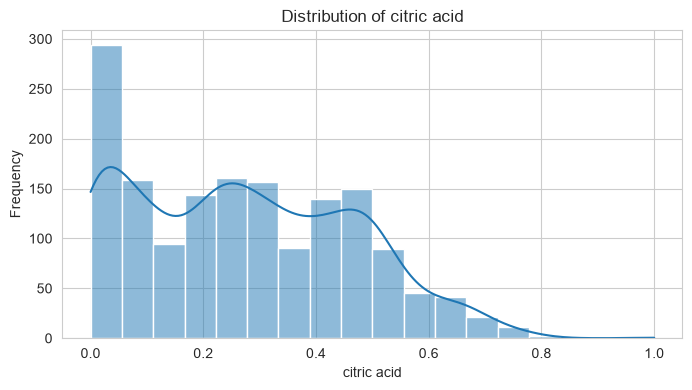

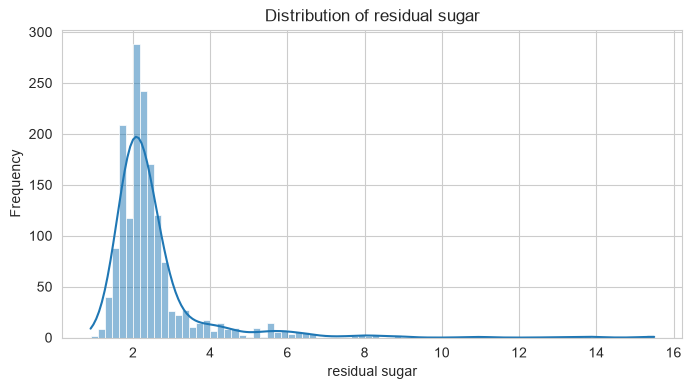

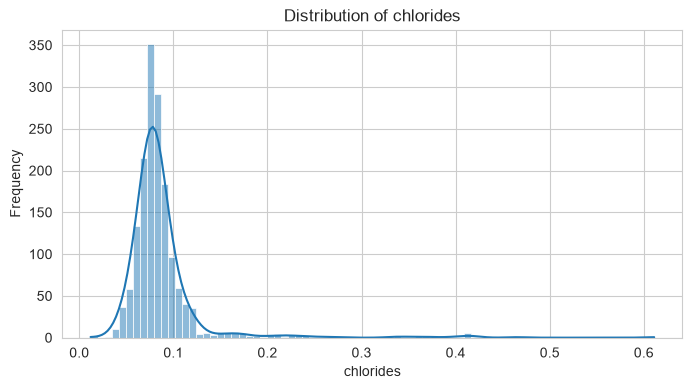

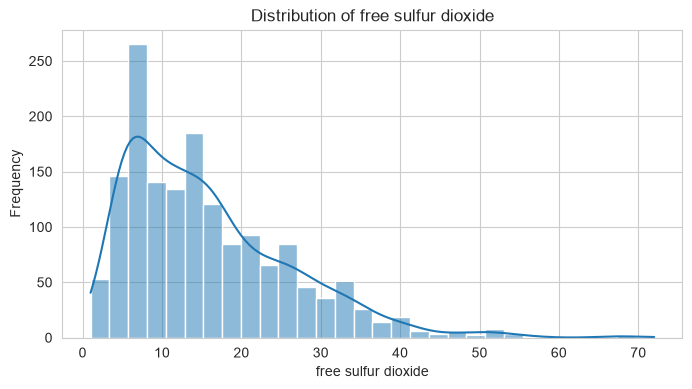

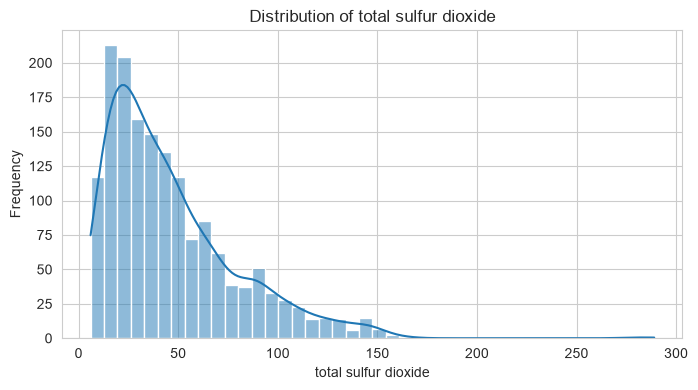

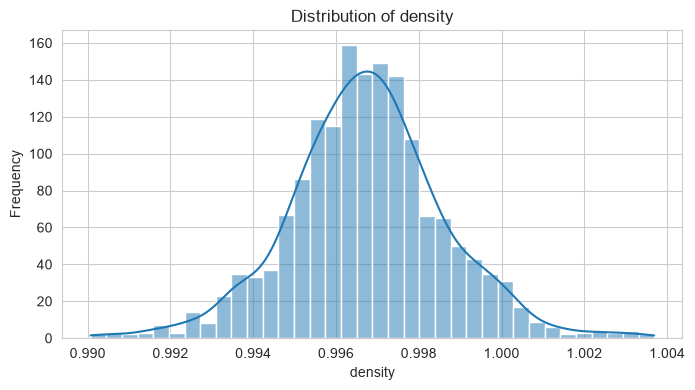

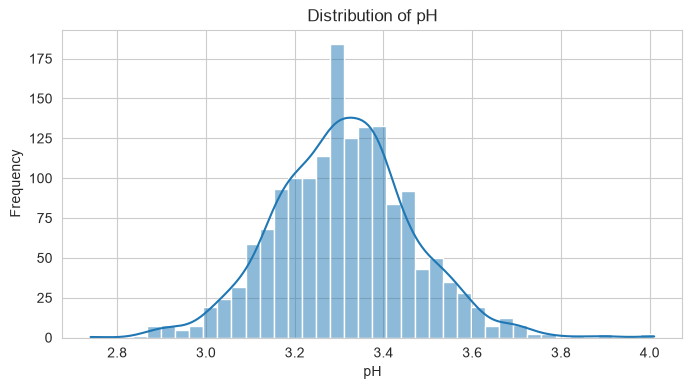

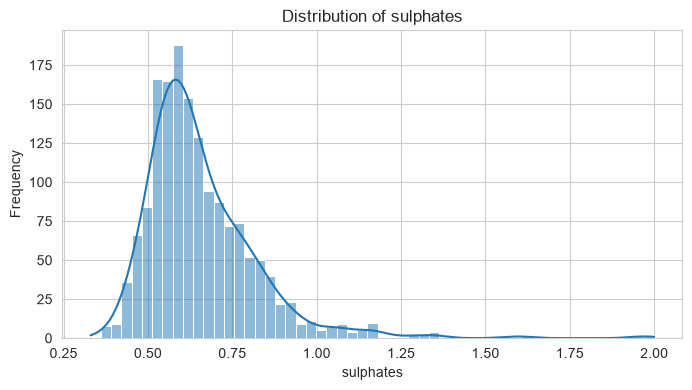

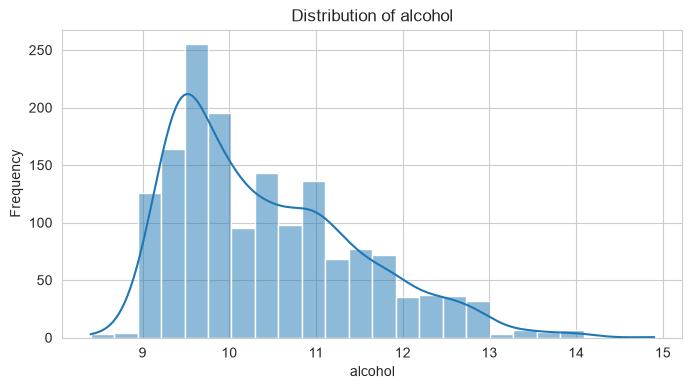

In [12]:
features = df.columns.drop('quality')

for feature in features:
    plt.figure(figsize=(8, 4))
    
    sns.histplot(data=df, x=feature, kde=True)
    
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
    
    plt.show()

### Observation

The physicochemical features show different distributions and scales.

For example, alcohol, density, acidity and sulphates have different numerical ranges. Therefore, standardization will be applied before training SGD and SVC models.

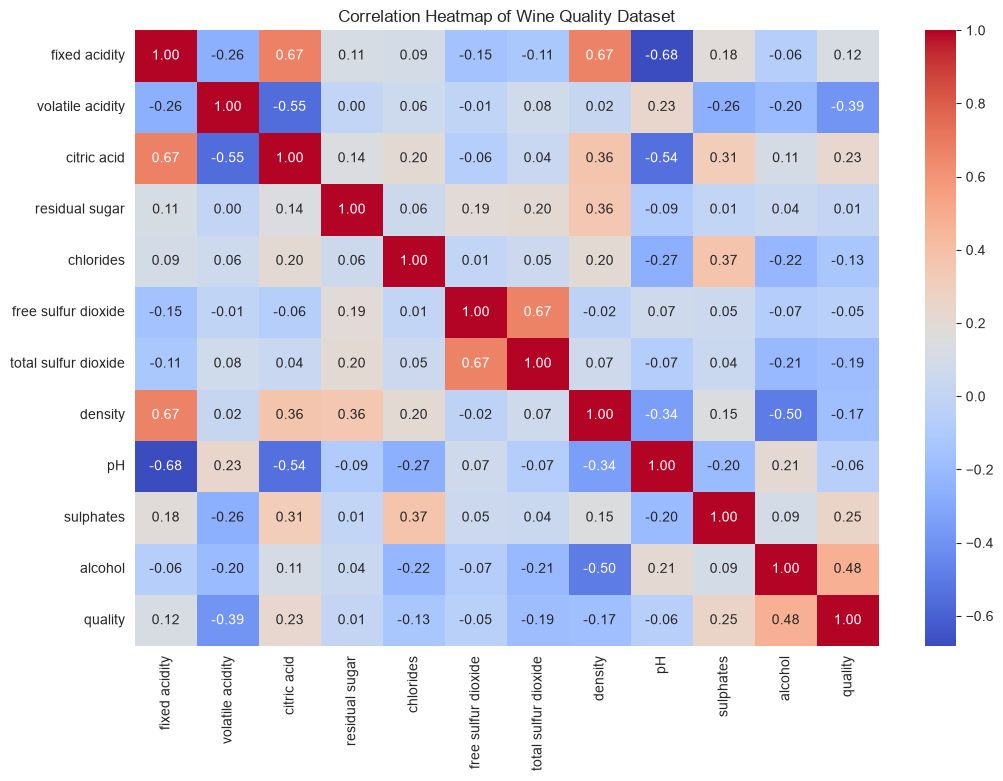

In [13]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap of Wine Quality Dataset')

plt.show()

### Observation

The correlation heatmap shows the relationships between the physicochemical properties and wine quality.

Alcohol generally shows a positive relationship with quality, while volatile acidity tends to show a negative relationship.

The correlations are not sufficient by themselves to predict quality, so multiple machine learning models will be trained using all available physicochemical features.

## Class Imbalance Analysis

The original quality variable contains several quality scores with unequal numbers of observations.

Strong class imbalance can cause a classifier to favour majority classes and perform poorly on minority classes.

To reduce the effect of sparse quality classes, the quality scores will be converted into three broader categories:

- Low: quality <= 5
- Medium: quality = 6
- High: quality >= 7

This creates a practical 3-class classification problem while retaining the distinction between lower, average and higher quality wines.

In [14]:
print("Original Quality Distribution:")
print(df['quality'].value_counts().sort_index())

print("\nPercentage Distribution:")
print((df['quality'].value_counts(normalize=True).sort_index() * 100).round(2))

Original Quality Distribution:
quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64

Percentage Distribution:
quality
3     0.63
4     3.31
5    42.59
6    39.90
7    12.45
8     1.13
Name: proportion, dtype: float64


In [15]:
def classify_quality(quality):
    if quality <= 5:
        return 'Low'
    elif quality == 6:
        return 'Medium'
    else:
        return 'High'


df['quality_category'] = df['quality'].apply(classify_quality)

df[['quality', 'quality_category']].head(10)

,quality,quality_category
0,5,Low
1,5,Low
2,5,Low
3,6,Medium
4,5,Low
5,5,Low
6,5,Low
7,7,High
8,7,High
9,5,Low


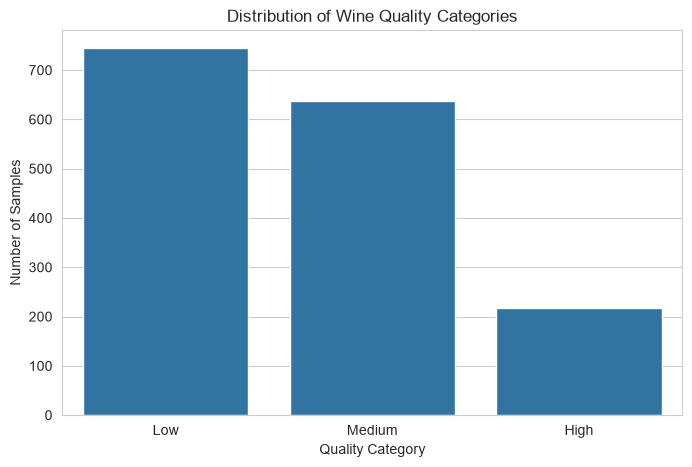

In [16]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='quality_category',
    order=['Low', 'Medium', 'High']
)

plt.title('Distribution of Wine Quality Categories')
plt.xlabel('Quality Category')
plt.ylabel('Number of Samples')

plt.show()

### Observation

After grouping the original quality scores into three categories, the classification problem becomes:

- Low quality
- Medium quality
- High quality

The classes may still be imbalanced, so class weighting will be used where supported by the selected classifiers.

## Preparing Features and Target

The original `quality` score and the newly created `quality_category` are separated from the physicochemical input features.

The target variable for classification is `quality_category`.

In [17]:
X = df.drop(columns=['quality', 'quality_category'])

y = df['quality_category']

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

print("\nTarget Classes:")
print(y.unique())

Feature Shape: (1599, 11)
Target Shape: (1599,)

Features:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']

Target Classes:
<ArrowStringArray>
['Low', 'Medium', 'High']
Length: 3, dtype: str


## Train-Test Split

The dataset is divided into 80% training data and 20% testing data.

Stratification is used to preserve approximately the same class proportions in both training and testing sets.

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

print("\nTraining Class Distribution:")
print(y_train.value_counts(normalize=True).round(3))

print("\nTesting Class Distribution:")
print(y_test.value_counts(normalize=True).round(3))

Training Data: (1279, 11)
Testing Data: (320, 11)

Training Class Distribution:
quality_category
Low       0.465
Medium    0.399
High      0.136
Name: proportion, dtype: float64

Testing Class Distribution:
quality_category
Low       0.466
Medium    0.400
High      0.134
Name: proportion, dtype: float64


## Feature Scaling

StandardScaler is used to standardize the physicochemical features.

Scaling is particularly important for SGD and SVC because these algorithms are sensitive to feature magnitudes.

Random Forest does not require feature scaling, so it will use the original features.

In [19]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


## Model 1: Random Forest Classifier

Random Forest is an ensemble learning algorithm that combines multiple decision trees.

It can capture nonlinear relationships between wine properties and quality categories.

In [20]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", round(rf_accuracy, 4))

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.7438

Classification Report:
              precision    recall  f1-score   support

        High       0.60      0.74      0.67        43
         Low       0.82      0.81      0.81       149
      Medium       0.72      0.67      0.69       128

    accuracy                           0.74       320
   macro avg       0.71      0.74      0.72       320
weighted avg       0.75      0.74      0.74       320



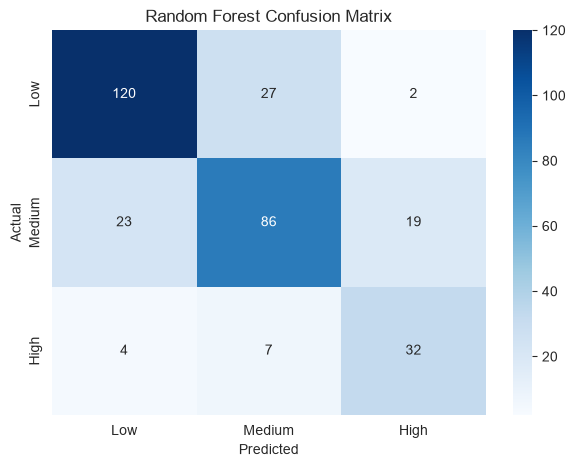

In [22]:
rf_cm = confusion_matrix(
    y_test,
    rf_pred,
    labels=['Low', 'Medium', 'High']
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    rf_cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Low', 'Medium', 'High'],
    yticklabels=['Low', 'Medium', 'High']
)

plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

### Random Forest Observation

The Random Forest model provides a baseline for predicting the three wine quality categories.

The classification report provides precision, recall and F1-score for each class, while the confusion matrix shows the types of predictions made by the model.

## Model 2: Stochastic Gradient Descent Classifier

SGD is a linear classification algorithm trained using stochastic gradient-based optimization.

The standardized features are used because SGD is sensitive to the scale of input variables.

In [24]:
sgd_model = SGDClassifier(
    loss='log_loss',
    max_iter=2000,
    random_state=42,
    class_weight='balanced'
)

sgd_model.fit(X_train_scaled, y_train)

sgd_pred = sgd_model.predict(X_test_scaled)

sgd_accuracy = accuracy_score(y_test, sgd_pred)

print("SGD Accuracy:", round(sgd_accuracy, 4))

print("\nClassification Report:")
print(classification_report(y_test, sgd_pred))

SGD Accuracy: 0.5813

Classification Report:
              precision    recall  f1-score   support

        High       0.33      0.51      0.40        43
         Low       0.69      0.78      0.73       149
      Medium       0.55      0.38      0.45       128

    accuracy                           0.58       320
   macro avg       0.53      0.56      0.53       320
weighted avg       0.59      0.58      0.57       320



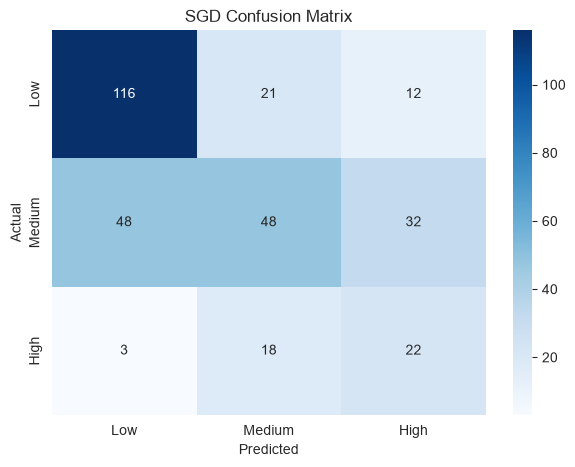

In [25]:
sgd_cm = confusion_matrix(
    y_test,
    sgd_pred,
    labels=['Low', 'Medium', 'High']
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    sgd_cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Low', 'Medium', 'High'],
    yticklabels=['Low', 'Medium', 'High']
)

plt.title('SGD Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

## Model 3: Support Vector Classifier

Support Vector Classifier attempts to find decision boundaries that separate different classes.

An RBF kernel is used to capture nonlinear relationships.

Standardized features are used for SVC.

In [26]:
svc_model = SVC(
    kernel='rbf',
    class_weight='balanced',
    random_state=42
)

svc_model.fit(X_train_scaled, y_train)

svc_pred = svc_model.predict(X_test_scaled)

svc_accuracy = accuracy_score(y_test, svc_pred)

print("SVC Accuracy:", round(svc_accuracy, 4))

print("\nClassification Report:")
print(classification_report(y_test, svc_pred))

SVC Accuracy: 0.6094

Classification Report:
              precision    recall  f1-score   support

        High       0.41      0.70      0.51        43
         Low       0.73      0.77      0.75       149
      Medium       0.57      0.40      0.47       128

    accuracy                           0.61       320
   macro avg       0.57      0.62      0.58       320
weighted avg       0.62      0.61      0.60       320



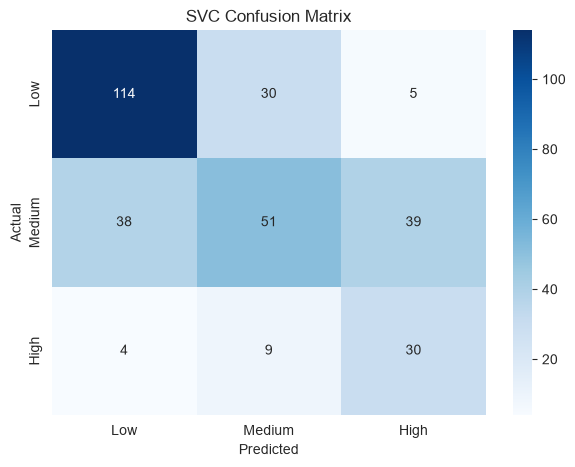

In [27]:
svc_cm = confusion_matrix(
    y_test,
    svc_pred,
    labels=['Low', 'Medium', 'High']
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    svc_cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Low', 'Medium', 'High'],
    yticklabels=['Low', 'Medium', 'High']
)

plt.title('SVC Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

## Random Forest Feature Importance

Random Forest provides feature importance scores that indicate which physicochemical properties contributed most to the model's predictions.

In [28]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance

,Feature,Importance
10,alcohol,0.167009
9,sulphates,0.116366
1,volatile acidity,0.109463
6,total sulfur dioxide,0.093112
2,citric acid,0.088674
7,density,0.085126
4,chlorides,0.075171
0,fixed acidity,0.071079
8,pH,0.067002
5,free sulfur dioxide,0.064195


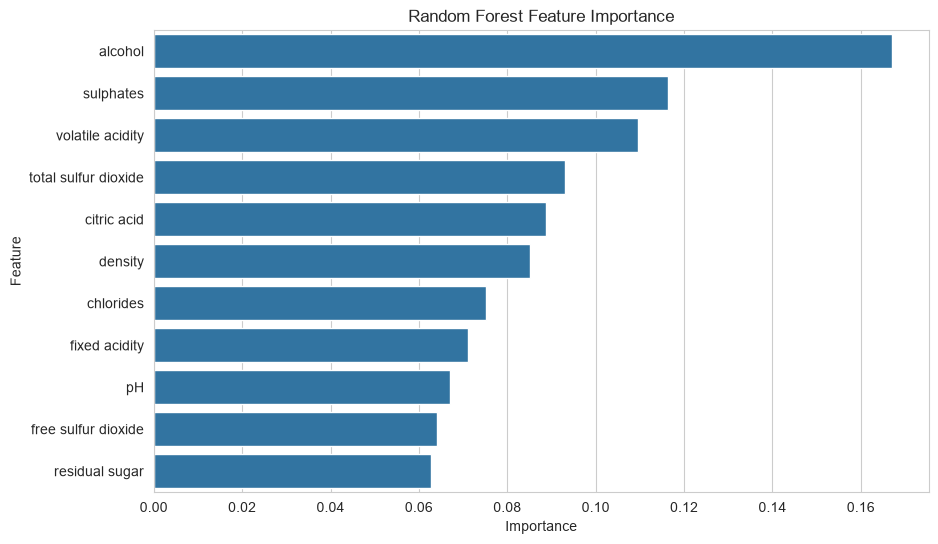

In [29]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance,
    x='Importance',
    y='Feature'
)

plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')

plt.show()

### Observation

The feature importance chart shows which physicochemical properties contributed most strongly to the Random Forest predictions.

The most important features can be considered useful indicators when analysing wine quality, although feature importance does not imply a direct causal relationship.

## Model Performance Comparison

The three classification models are compared using their test-set accuracy.

The comparison helps identify the model that provides the strongest overall predictive performance on the held-out data.

In [30]:
comparison = pd.DataFrame({
    'Model': [
        'Random Forest',
        'SGD',
        'SVC'
    ],
    'Accuracy': [
        rf_accuracy,
        sgd_accuracy,
        svc_accuracy
    ]
})

comparison = comparison.sort_values(
    by='Accuracy',
    ascending=False
).reset_index(drop=True)

comparison

,Model,Accuracy
0,Random Forest,0.743750
1,SVC,0.609375
2,SGD,0.581250


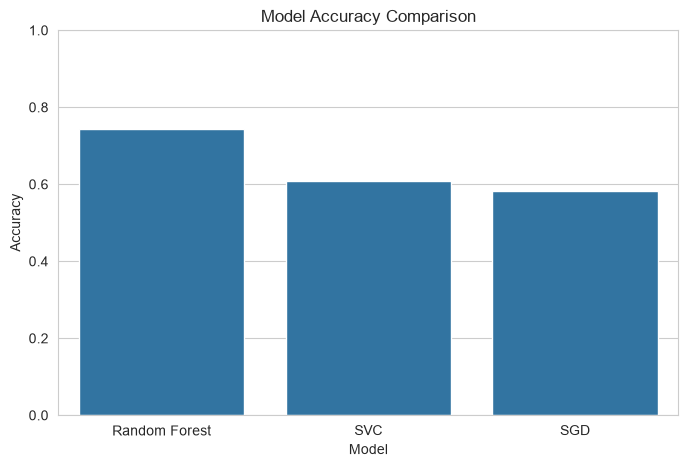

In [31]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=comparison,
    x='Model',
    y='Accuracy'
)

plt.title('Model Accuracy Comparison')
plt.xlabel('Model')
plt.ylabel('Accuracy')

plt.ylim(0, 1)

plt.show()

In [32]:
best_model = comparison.iloc[0]

print("Best Performing Model:", best_model['Model'])
print("Accuracy:", round(best_model['Accuracy'], 4))

Best Performing Model: Random Forest
Accuracy: 0.7438


# Conclusion

In this project, three machine learning classification models were trained to predict wine quality categories based on physicochemical properties.

The models achieved the following test accuracies:

- Random Forest: 74.38%
- SVC: 60.94%
- SGD: 58.13%

Among the three models, **Random Forest performed the best with an accuracy of 74.38%**. It outperformed both SVC and SGD on the test dataset.

Random Forest was selected as the most suitable model for deployment because it provided the highest predictive accuracy and can capture nonlinear relationships between the physicochemical properties and wine quality.

The feature importance analysis from Random Forest also helps identify the chemical properties that contribute most to the predictions.

However, because the wine quality classes are imbalanced, accuracy alone should not be used to judge the model. Precision, recall and F1-score should also be considered, especially for the minority quality categories.

### Key Findings

- Wine quality can be predicted using physicochemical properties.
- The quality classes are imbalanced.
- The quality scores were grouped into Low, Medium and High categories.
- Stratified train-test splitting was used to preserve class proportions.
- Random Forest achieved the highest accuracy of **74.38%**.
- Random Forest is the best-performing model among the three tested models.